# Ethiopia Climate Data – Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import pandas as pd
df = pd.read_csv('../data/ethiopia.csv')
df['Country'] = 'Ethiopia'
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4108, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [ ]:

df.info()
print("\nCount of -999 values per column:")
print((df == -999).sum())

<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
 12  Country      4108 non-null   str    
dtypes: float64(10), int64(2), str(1)
memory usage: 417.3 KB

Count of -999 values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS       

In [ ]:

df.replace(-999, np.nan, inplace=True)
print("Missing values after replacement:")
print(df.isna().sum())

Missing values after replacement:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [ ]:

def create_date(year, doy):
    return pd.to_datetime(year.astype(str) + doy.astype(str).str.zfill(3), format='%Y%j')

df['Date'] = create_date(df['YEAR'], df['DOY'])
df['Month'] = df['Date'].dt.month
df.set_index('Date', inplace=True)
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,1


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found.")

Number of duplicate rows: 0
No duplicates found.


## Summary Statistics of Numeric Columns

* **Mean vs median** – if they differ a lot, the data is skewed.
* **Standard deviation** – how much the variable fluctuates.
* **Min / Max** – look for unrealistic values (should be gone after -999 replacement).



In [ ]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

summary = df[numeric_cols].describe()
summary

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


In [ ]:
missing_count = df[numeric_cols].isna().sum()
missing_pct = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing count': missing_count,
    'Missing percent': missing_pct
})

print("Missing values per column:")
missing_table

high_missing = missing_table[missing_table['Missing percent'] > 5]
if not high_missing.empty:
    print("\nColumns with >5% missing values:")
    print(high_missing)
else:
    print("\nNo column has more than 5% missing values.")

Missing values per column:

No column has more than 5% missing values.


In [ ]:

outlier_vars = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

outlier_counts = {}
for col in outlier_vars:
    
    col_clean = df[col].dropna()
    z = np.abs(stats.zscore(col_clean))
    outliers = (z > 3).sum()
    outlier_counts[col] = outliers
    print(f"{col}: {outliers} outliers ({(outliers/len(col_clean))*100:.2f}%)")

T2M: 3 outliers (0.07%)
T2M_MAX: 0 outliers (0.00%)
T2M_MIN: 18 outliers (0.44%)
PRECTOTCORR: 95 outliers (2.31%)
RH2M: 13 outliers (0.32%)
WS2M: 3 outliers (0.07%)
WS2M_MAX: 5 outliers (0.12%)


In [ ]:
def cap_outliers(df, columns, threshold=3):
    df_capped = df.copy()
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        upper = mean + threshold * std
        lower = mean - threshold * std
        df_capped[col] = df[col].clip(lower=lower, upper=upper)
    return df_capped

df_clean = cap_outliers(df, outlier_vars)
print("Outliers have been capped to the 3‑standard‑deviation limits.")

Outliers have been capped to the 3‑standard‑deviation limits.


In [ ]:

df_clean[numeric_cols] = df_clean[numeric_cols].ffill()
df_clean[numeric_cols] = df_clean[numeric_cols].bfill()
final_missing = df_clean[numeric_cols].isna().sum().sum()
print(f"Remaining missing values after filling: {final_missing}")

Remaining missing values after filling: 0


In [ ]:

df_clean.to_csv('../data/ethiopia_clean.csv')
print("Cleaned data saved to data/ethiopia_clean.csv")
print(f"Final shape: {df_clean.shape}")

Cleaned data saved to data/ethiopia_clean.csv
Final shape: (4108, 14)


## Temperature Trend (2015–2026)

We plot the monthly average temperature to identify long‑term trends, seasonality, and the warmest/coolest months.

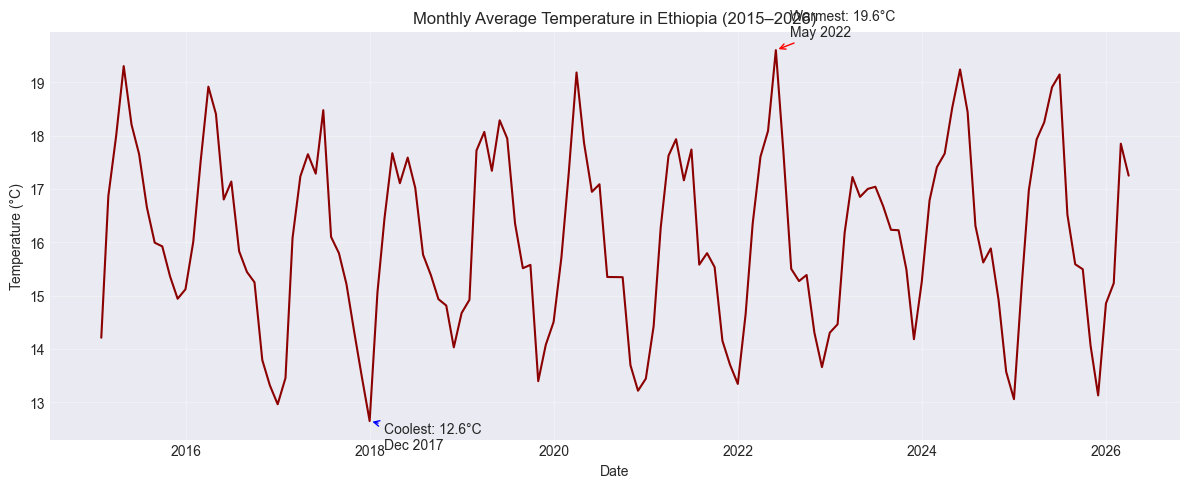

In [ ]:

monthly_temp = df_clean['T2M'].resample('ME').mean()

warmest_date = monthly_temp.idxmax()
warmest_val = monthly_temp.max()
coolest_date = monthly_temp.idxmin()
coolest_val = monthly_temp.min()

plt.figure(figsize=(12, 5))
plt.plot(monthly_temp.index, monthly_temp.values, color='darkred', linewidth=1.5)
plt.title('Monthly Average Temperature in Ethiopia (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.grid(alpha=0.3)

plt.annotate(f'Warmest: {warmest_val:.1f}°C\n{warmest_date.strftime("%b %Y")}',
             xy=(warmest_date, warmest_val),
             xytext=(10, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.annotate(f'Coolest: {coolest_val:.1f}°C\n{coolest_date.strftime("%b %Y")}',
             xy=(coolest_date, coolest_val),
             xytext=(10, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue'))

plt.tight_layout()
plt.show()
    

## Monthly Total Precipitation



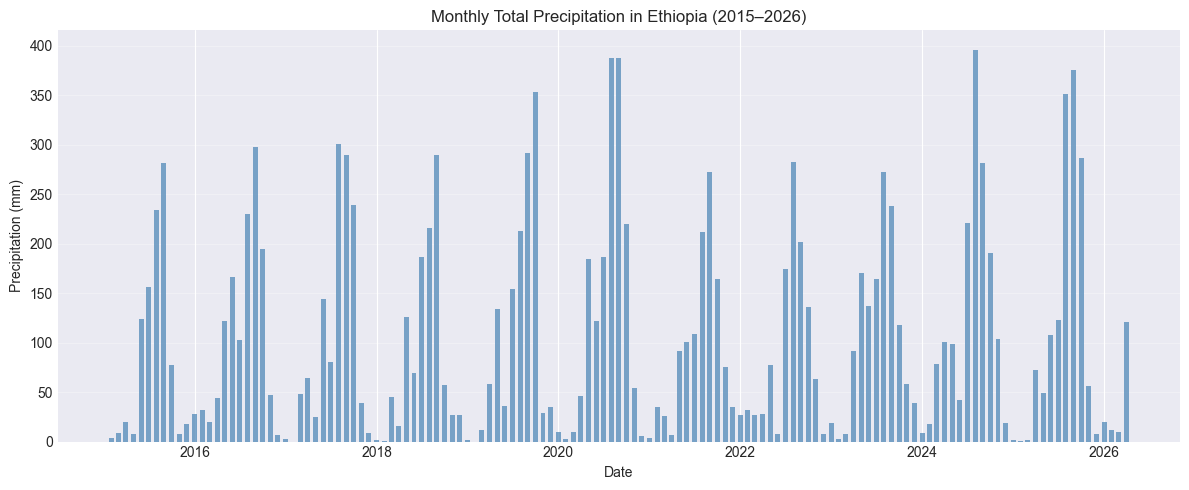

Peak rainy months (by historical average): [8, 7, 9]


In [ ]:
monthly_precip = df_clean['PRECTOTCORR'].resample('ME').sum()

plt.figure(figsize=(12, 5))
plt.bar(monthly_precip.index, monthly_precip.values, width=20, color='steelblue', alpha=0.7)
plt.title('Monthly Total Precipitation in Ethiopia (2015–2026)')
plt.ylabel('Precipitation (mm)')
plt.xlabel('Date')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

monthly_avg = df_clean.groupby('Month')['PRECTOTCORR'].mean()
peak_months = monthly_avg.nlargest(3).index.tolist()
print(f"Peak rainy months (by historical average): {peak_months}")

## Correlation Between Climate Variables



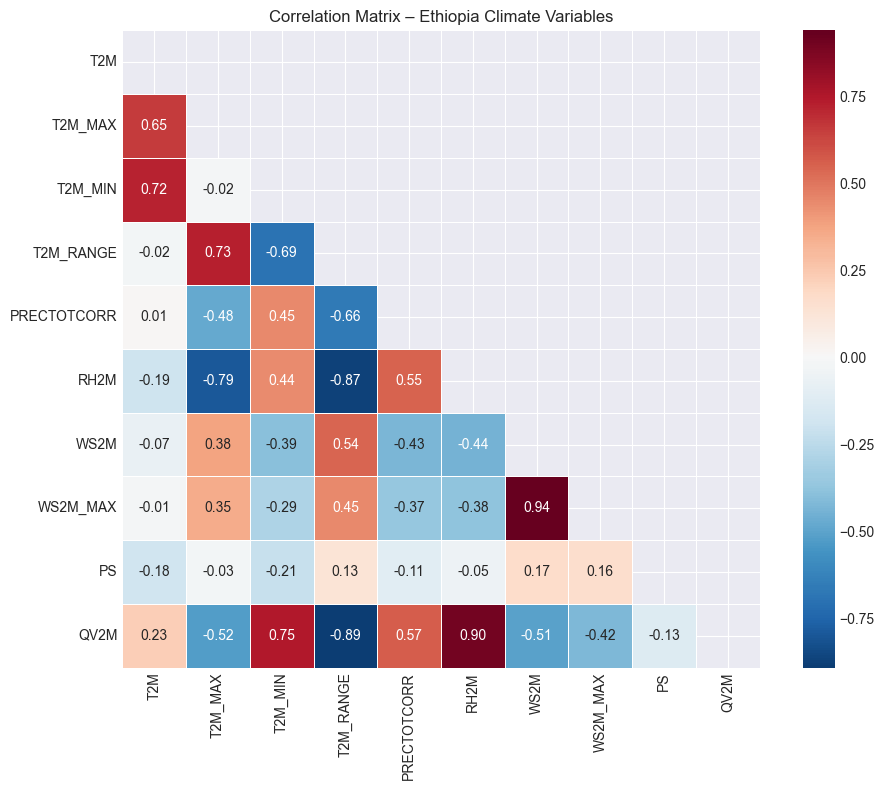

Strongest three correlations:
1. WS2M vs WS2M_MAX: 0.941
2. WS2M_MAX vs WS2M: 0.941
3. QV2M vs RH2M: 0.905


In [ ]:
plt.figure(figsize=(10, 8))
corr = df_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix – Ethiopia Climate Variables')
plt.tight_layout()
plt.show()


corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # remove diagonal
print("Strongest three correlations:")
for i in range(3):
    print(f"{i+1}. {corr_pairs.index[i][0]} vs {corr_pairs.index[i][1]}: {corr_pairs.values[i]:.3f}")

## Relationship Plots



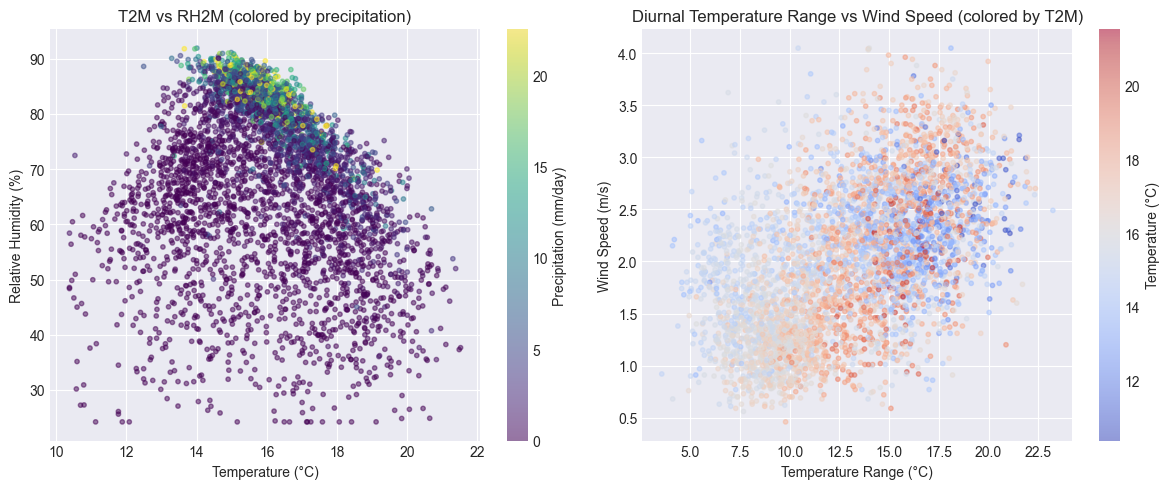

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


ax1 = axes[0]
sc1 = ax1.scatter(df_clean['T2M'], df_clean['RH2M'], c=df_clean['PRECTOTCORR'], 
                  cmap='viridis', alpha=0.5, s=10)
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')
ax1.set_title('T2M vs RH2M (colored by precipitation)')
plt.colorbar(sc1, ax=ax1, label='Precipitation (mm/day)')


ax2 = axes[1]
sc2 = ax2.scatter(df_clean['T2M_RANGE'], df_clean['WS2M'], c=df_clean['T2M'],
                  cmap='coolwarm', alpha=0.5, s=10)
ax2.set_xlabel('Temperature Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')
ax2.set_title('Diurnal Temperature Range vs Wind Speed (colored by T2M)')
plt.colorbar(sc2, ax=ax2, label='Temperature (°C)')

plt.tight_layout()
plt.show()

## Daily Precipitation Distribution



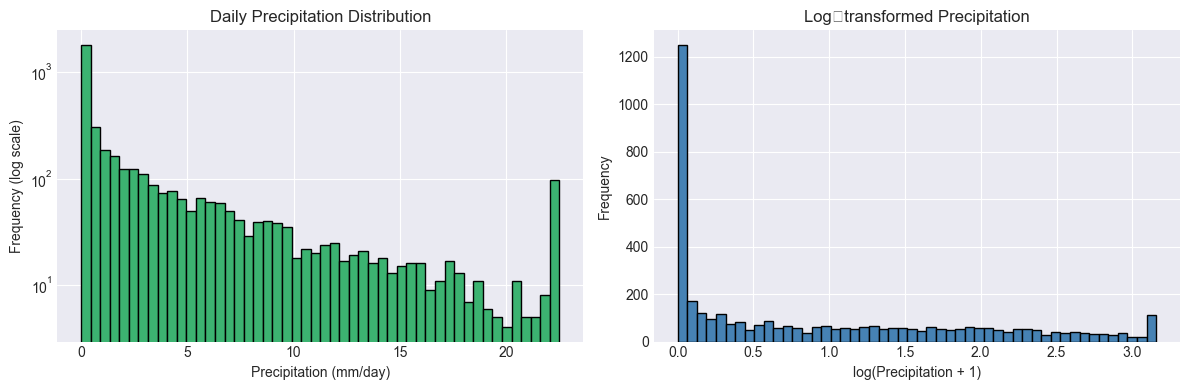

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(df_clean['PRECTOTCORR'], bins=50, color='mediumseagreen', edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Daily Precipitation Distribution')


axes[1].hist(np.log1p(df_clean['PRECTOTCORR']), bins=50, color='steelblue', edgecolor='black')
axes[1].set_xlabel('log(Precipitation + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log‑transformed Precipitation')

plt.tight_layout()
plt.show()

## Bubble Chart: Temperature vs Humidity (size = precipitation)



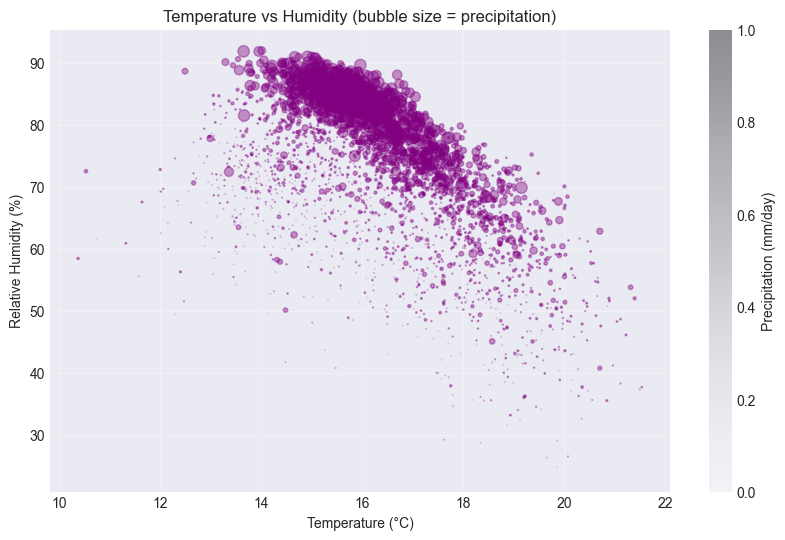

In [ ]:
plt.figure(figsize=(10, 6))
bubble = plt.scatter(df_clean['T2M'], df_clean['RH2M'], 
                     s=df_clean['PRECTOTCORR']*3, alpha=0.4, c='purple')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Humidity (bubble size = precipitation)')
plt.colorbar(bubble, label='Precipitation (mm/day)')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
print("Final dataset summary:")
print(f"Period: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"Number of days: {len(df_clean)}")
print(f"Columns available: {list(df_clean.columns)}")

Final dataset summary:
Period: 2015-01-01 00:00:00 to 2026-03-31 00:00:00
Number of days: 4108
Columns available: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Month']
